# Attention Mechanisms
An **attention mechanism** learns how to score the *importance* of each item in the input.
It takes into account *context* to infer the importance of the items.
## Attention mechanisms learn relative input importance

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import torchvision
from torchvision import transforms, datasets
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
from sklearn.metrics import accuracy_score

# Import dl_utils
import sys, os
sys.path.insert(0, os.path.abspath("../DL_utils_EZA"))
%load_ext autoreload
%autoreload 2
from dl_utils import *
print("dl_utils loaded ✅")

# ── Device setup ──────────────────────────────────────────────────────────────
# cudnn.benchmark = True  → optimal for fixed-size inputs (convolutional GANs)
# cudnn.benchmark = False → safer for FC-only GANs with variable shapes
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/tmp/ipykernel_24239/1858903610.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


dl_utils loaded ✅
Device : cuda
GPU    : NVIDIA GeForce RTX 2080 Ti
VRAM   : 11.35 GB


In [2]:
# Downloading the MNIST data set
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())


In [4]:
class LargestDigit(Dataset):
    """ 
    Creates a modified version of a dataset where some number of samples are taken, 
    and the true labes is the largest label sampled. When used with MNIST, the labels
    correspond to their values (g.g., digit : '6' has label 6)
    """

    def __init__(self, dataset, toSample=3):
        """ 
        dataset:  the data set to sample from (e.g., MNIST)
        toSample: the number of samples to take from the dataset for each new sample
        """
        self.dataset = dataset
        self.toSample = toSample

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        # Randomly select `toSample` samples from the dataset
        selected = np.random.randint(0, len(self.dataset), size=self.toSample)
        # Stack the selected samples and find the maximum label
        x_new = torch.stack([self.dataset[i][0] for i in selected])
        y_new = max([self.dataset[i][1] for i in selected])
        
        return x_new, y_new

In [5]:
# Training the baseline model
B = 128
epochs = 30
largest_train = LargestDigit(mnist_data_train, toSample=3)
largest_test = LargestDigit(mnist_data_test, toSample=3)

# Data Loader
mnist_train_loader = DataLoader(largest_train, 
                                batch_size=B, 
                                shuffle=True, 
                                num_workers=4, 
                                pin_memory=True, 
                                persistent_workers=True,
                                drop_last=True
                                )
mnist_test_loader = DataLoader(largest_test, 
                               batch_size=B,
                               shuffle=False,
                               num_workers=4,
                               pin_memory=True, 
                               persistent_workers=True
                               )

True label is =  8


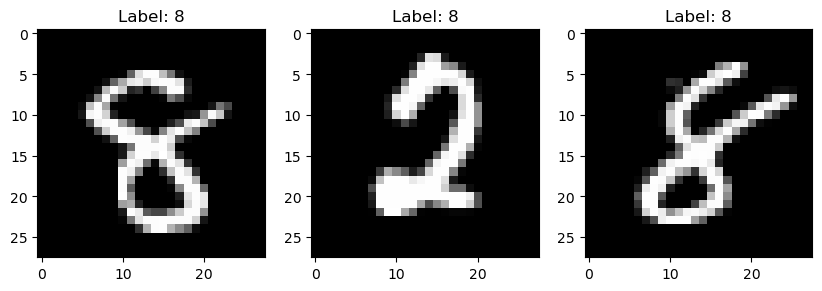

In [7]:
# Plot the transformed dataset to show that the set can 
# teach the model to ignore the smaller digists
x, y = largest_train[0]
f, axarr = plt.subplots(1, 3, figsize=(10, 10))
for i in range(3):
    axarr[i].imshow(x[i][0], cmap='gray')
    axarr[i].set_title(f"Label: {y}")
print('True label is = ', y)

In [8]:
# Train the baseline model with toy MNIST problem
neurons = 256
classes = 10
simpleNet = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784*3, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, classes)
)

In [9]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run
torch.backends.cudnn.benchmark = False  # True is better for CNNs with fixed input sizes

# train_network_EZA instructions:
"""
                      (model, 
                      loss_func, 
                      train_loader, 
                      test_loader=None,
                      score_funcs=None, 
                      epochs=300, 
                      device='cpu',                      
                      checkpoint_file=None, 
                      resume_from_checkpoint=None,
                      checkpoint_every_x=None, 
                      use_amp=True,
                      optimizer=None,
                      lr_schedule=None,
                      val_loader=None)seg_results

    Train neural networks with EZA improvements.

    Keyword arguments:
    model                  -- PyTorch model to train
    loss_func              -- loss function (outputs, labels) -> score
    train_loader           -- DataLoader returning (input, label) tuples
    test_loader            -- Optional DataLoader for evaluation after every epoch
    score_funcs            -from sklearn.metrics import accuracy_score- dict of scoring functions e.g. {'Accuracy': accuracy_score}
    epochs                 -- number of training epochs
    device                 -- 'cuda' or 'cpu'
    checkpoint_file        -- path to save final checkpoint
    resume_from_checkpoint -- path to load checkpoint from to resume training
    checkpoint_every_x     -- save intermediate checkpoint every X epochs
    use_amp                -- enable Automatic Mixed Precision (RTX GPUs)
    optimizer              -- if none selected it uses AdamW optimizer
    lr_schedule            -- uses the ReduceLROPlateu function.
    val_loader             -- Optional PyTorch DataLoader to evaluate on after every epoch

    Returns: pd.DataFrame with training history

    ---------------seg_results---------------------------------------------------------------------------
    
    Improves over the train_simple_network:
    - Uses new optimizers and schedulers

"""

simple_results = train_network_EZA(simpleNet,
                                   nn.CrossEntropyLoss(),
                                   mnist_train_loader,
                                   val_loader=mnist_test_loader,
                                   epochs=10,
                                   use_amp=True,
                                   score_funcs= {'Accuracy': accuracy_score},
                                   device=device)

Epoch: 100%|██████████| 10/10 [03:06<00:00, 18.69s/it]


<Axes: xlabel='epoch', ylabel='val loss'>

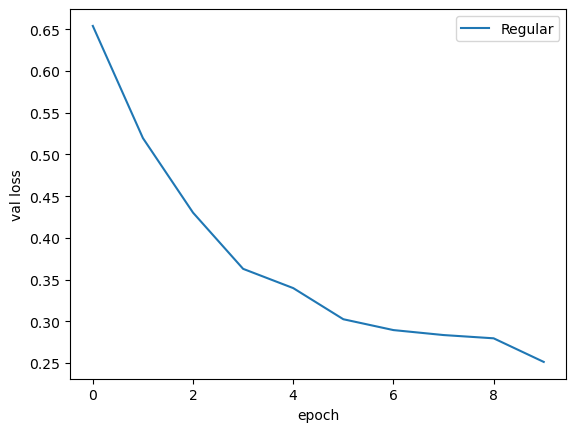

In [10]:
sns.lineplot(x="epoch", y="val loss", data=simple_results, label="Regular")

<Axes: xlabel='epoch', ylabel='val Accuracy'>

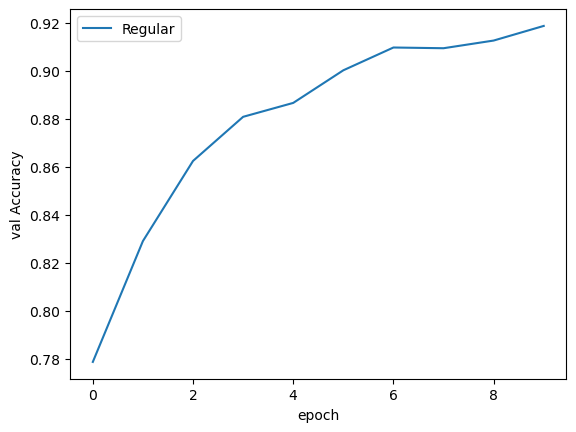

In [24]:
sns.lineplot(x="epoch", y="val Accuracy", data=simple_results, label="Regular")

### Implementing a simple **Attention Mechanism**
We need to convert the bag of images  (B,T,C,W,H) into a bag of feature vectors (B, T, C * W * H) using the `nn.Flatten` function.

In [26]:
# Flatten function
class Flatten2(nn.Module):
    """ 
    Takes a vector of shape (A,B,C,D, ...)
    and flattens all but the first two dimensions, returning a vector of shape (A,B,C*D*...)
    """
    def forward(self, input):
        return input.view(input.size(0), input.size(1), -1)

**DEFINING THE COMBINER MODULE**\
A module that takes the attention weights $a$ with the extracted feature representations $h_1, h_2, ...h_T$ and computes the  the weighted average. Call the `Combiner`.

In [27]:
# The Combiner Module
class Combiner(nn.Module):
    """
    Combines a set of vectors into a single vector using attention weights.
    """
    def __init__(self, featureExtraction, weightSelection):
        """ 
        featureExtraction: a network that takes an input shape (B,T,D) and ouputs a new
        shape (B,T,D') where D' is the new feature dimension
        weightSelection: a network that takes an input shape (B,T,1) or (B,T). it shoule be 
        normalized, so that T values sum to 1.
        """
        super(Combiner, self).__init__()
        self.featureExtraction = featureExtraction
        self.attention = weightSelection
        

    def forward(self, input):
        """ 
        input:  tensor of shape (B, T, D)
        return: new tensor of shape (B, D') where D' is the new feature dimension
        """
        features = self.featureExtraction(input)  # (B, T, D')
        weights = self.attention(features)            # (B, T, 1) or (B, T)
        if len(weights.shape) == 2:
            weights = weights.unsqueeze(2)  # (B, T, 1)
        r = features * weights  # (B, T, D')
        return torch.sum(r, dim=1)  # (B, D')


**DEFINING A BACKBONE NETWORK**
Define the attention model for this problem.It will learn a good representation of **$h_i$**\
Define variables: 
- T = items in the bag
- D = number of features

In [29]:
# Variables
# T = 3
# D = 784
D_prime = 256

# xb, yb = next(iter(mnist_train_loader))

# flatten2 = Flatten2()
# xb_flat = flatten2(xb) 

backboneNetwork = nn.Sequential(
    Flatten2(),
    nn.Linear(D, D_prime),
    nn.LeakyReLU(),
    nn.Linear(D_prime, D_prime),
    nn.LeakyReLU(),
    nn.Linear(D_prime, D_prime),
    nn.LeakyReLU())

**DEFINING AN ATTENTION SUBNETWORK**

In [30]:
attentionMechanism = nn.Sequential(
    nn.Linear(D_prime, D_prime),
    nn.LeakyReLU(),
    nn.Linear(D_prime, 1),
    nn.Softmax(dim=1),   # <- normalize over T, not over the last dim
)

In [31]:
# Training a small attention-based model
small_attention_model = nn.Sequential(
    Combiner(backboneNetwork, attentionMechanism),
    nn.BatchNorm1d(D_prime),
    nn.Linear(D_prime, D_prime),
    nn.LeakyReLU(),
    nn.BatchNorm1d(D_prime),
    nn.Linear(D_prime, classes),
).to(device)

In [33]:

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run
torch.backends.cudnn.benchmark = False  # True is better for CNNs with fixed input sizes

optimizer = torch.optim.AdamW(small_attention_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

# Train the small attention-based model
small_attn_results = train_network_EZA(
    model=small_attention_model,
    loss_func=nn.CrossEntropyLoss(),
    train_loader=mnist_train_loader,
    val_loader=mnist_test_loader,
    score_funcs={'Accuracy': accuracy_score},
    epochs=10,
    device=device,
    use_amp=True,          # safe: Turing supports fp16, GradScaler already wired in dl_utils
    optimizer=optimizer,
    lr_schedule=scheduler
)

Epoch: 100%|██████████| 10/10 [03:05<00:00, 18.55s/it]


<Axes: xlabel='epoch', ylabel='val loss'>

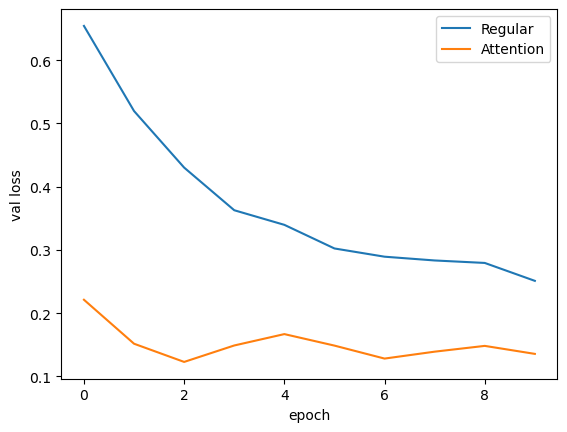

In [34]:
sns.lineplot(x="epoch", y="val loss", data=simple_results, label="Regular")
sns.lineplot(x="epoch", y="val loss", data=small_attn_results, label="Attention")

<Axes: xlabel='epoch', ylabel='val Accuracy'>

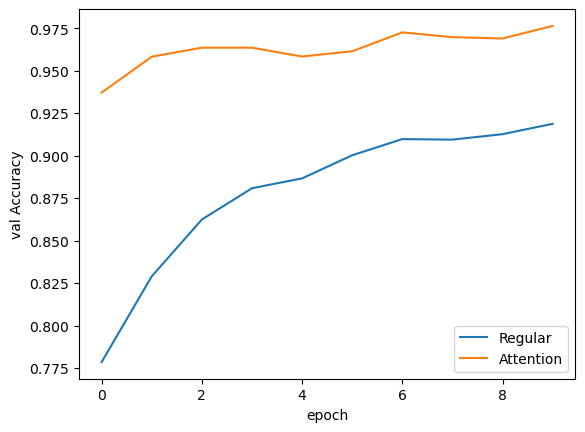

In [35]:
sns.lineplot(x="epoch", y="val Accuracy", data=simple_results, label="Regular")
sns.lineplot(x="epoch", y="val Accuracy", data=small_attn_results, label="Attention")

True Label is =  5


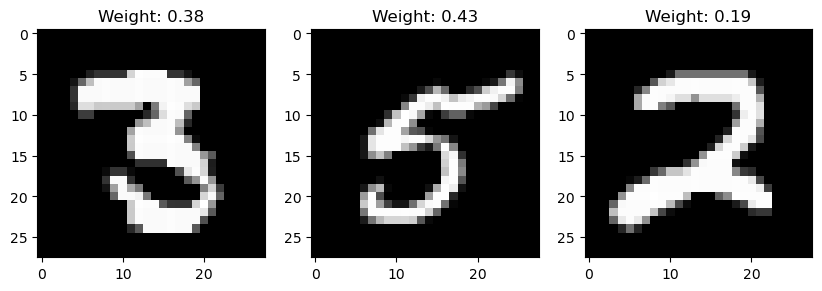

In [47]:
# Review how the attention mechanism select the results.
x, y = largest_train[0]
x = x.to(device)

with torch.no_grad():
    weigths = attentionMechanism(backboneNetwork(x.unsqueeze(0)))
    weigths = weigths.cpu().numpy().ravel()

f, axarr = plt.subplots(1, 3, figsize=(10, 10))
for i in range(3):
    axarr[i].imshow(x[i][0].cpu(), cmap='gray')
    axarr[i].set_title(f"Weight: {weigths[i]:.2f}")

print("True Label is = ", y)

/tmp/ipykernel_24239/2178763064.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/efrain/anaconda3/envs/pytorch-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


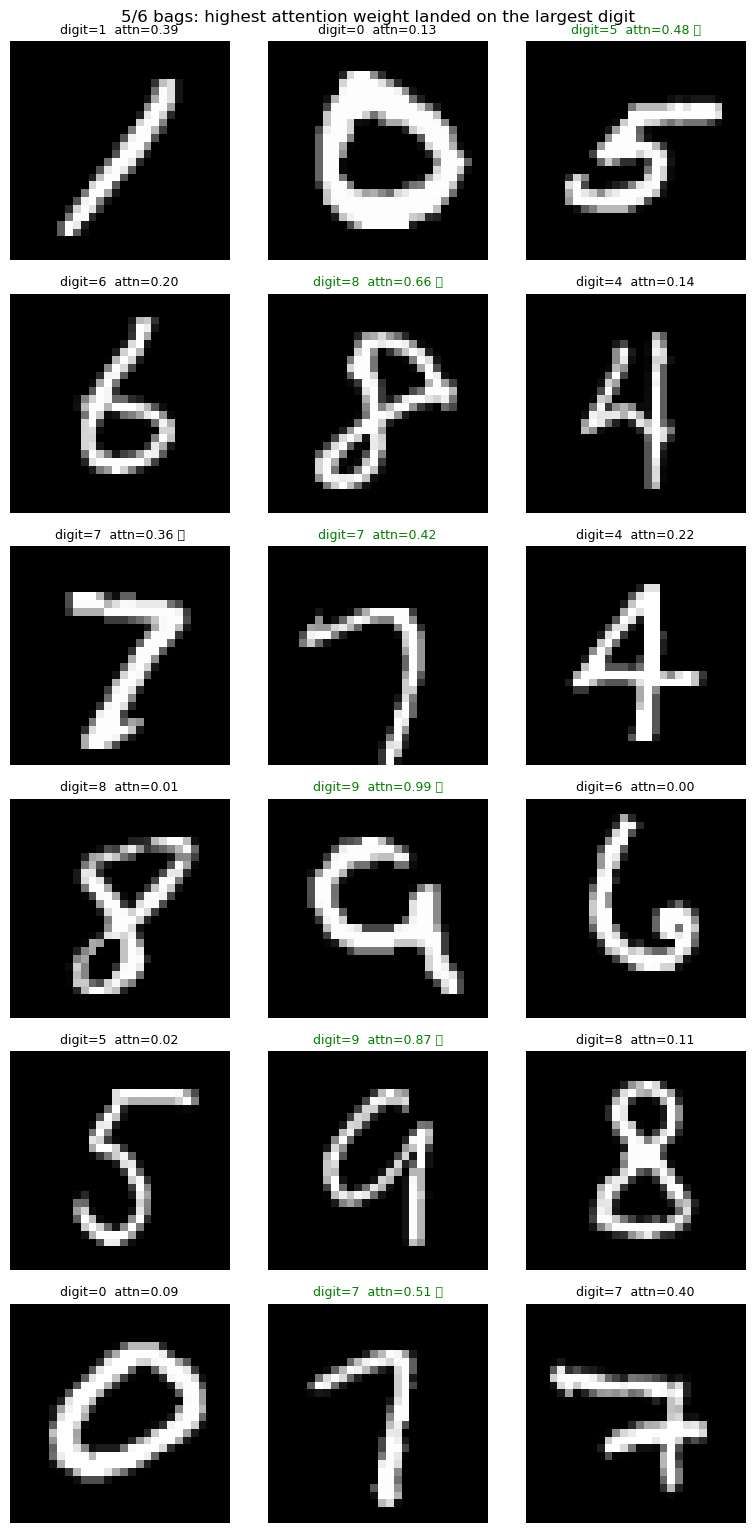

In [49]:
def visualize_attention(backbone, attention, debug_dataset, device, n_examples=6, seed=0):
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(debug_dataset), n_examples, replace=False)
    backbone.eval(); attention.eval()

    fig, axarr = plt.subplots(n_examples, 3, figsize=(8, 2.6 * n_examples))
    n_correct = 0

    with torch.no_grad():
        for row, idx in enumerate(indices):
            x, y, item_labels = debug_dataset[idx]          # x: (T, C, H, W)
            xb = x.unsqueeze(0).to(device)                   # (1, T, C, H, W)

            features = backbone(xb)                          # (1, T, D')
            weights = attention(features).squeeze().cpu().numpy()   # (T,)

            true_idx = item_labels.argmax().item()
            attn_idx = weights.argmax()
            n_correct += int(attn_idx == true_idx)

            for col in range(3):
                ax = axarr[row, col]
                ax.imshow(x[col, 0].numpy(), cmap='gray')
                ax.axis('off')
                marker = " ✅" if col == true_idx else ""
                ax.set_title(f"digit={item_labels[col].item()}  attn={weights[col]:.2f}{marker}",
                              fontsize=9, color='green' if col == attn_idx else 'black')

    plt.suptitle(f"{n_correct}/{n_examples} bags: highest attention weight landed on the largest digit")
    plt.tight_layout()
    plt.show()

visualize_attention(backboneNetwork, attentionMechanism, debug_test, device, n_examples=6)

In [50]:
def attention_alignment_rate(backbone, attention, debug_dataset, device,
                              n_samples=1000, batch_size=128, seed=0):
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(debug_dataset), n_samples, replace=False)
    backbone.eval(); attention.eval()
    correct = 0

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            xs, labels = [], []
            for idx in indices[start:start + batch_size]:
                x, y, item_labels = debug_dataset[idx]
                xs.append(x); labels.append(item_labels)
            xb = torch.stack(xs).to(device)
            labels = torch.stack(labels)

            weights = attention(backbone(xb)).squeeze(-1).cpu()
            correct += (labels.argmax(dim=1) == weights.argmax(dim=1)).sum().item()

    rate = correct / n_samples
    print(f"Attention correctly focused on the largest digit in "
          f"{correct}/{n_samples} bags ({rate*100:.1f}%)")
    return rate

attention_alignment_rate(backboneNetwork, attentionMechanism, debug_test, device, n_samples=1000)

Attention correctly focused on the largest digit in 833/1000 bags (83.3%)


0.833

## Adding *CONTEXT*
